In [24]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym

# @title Diseño del Agente Monte Carlo

class TaxiAgent:
    def __init__(
        self,
        env: gym.Env,

        epsilon: float =0.4,

        initial_epsilon: float = 1.0,
        epsilon_decay: float = 0.01,
        final_epsilon: float = 0.01,

        discount_factor: float = 1.0,
        decay=False
    ):
        """Inicializa todo lo necesario para el aprendizaje"""
        self.env = env
        self.epsilon = epsilon
        self.discount_factor = discount_factor
        self.decay = decay
        self.initial_epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon
        
        # Track learning progress
        self.training_error = []

        # Inicializamos la tabla Q y el contador de visitas (N)
        self.Q = np.zeros([env.observation_space.n, env.action_space.n])
        self.n_visits = np.zeros([env.observation_space.n, env.action_space.n])

    def get_action(self, state) -> int:
        """
        Política epsilon-greedy: 
        Con probabilidad epsilon, exploramos tomando una acción aleatoria.
        Con probabilidad (1 - epsilon), explotamos tomando la mejor acción conocida.
        """
        if np.random.random() < self.epsilon:
            return self.env.action_space.sample()
        else:
            return int(np.argmax(self.Q[state, :]))

    def update(
        self,
        episode
    ):
        """
        Algoritmo Monte Carlo (Every-Visit).
        Actualiza los valores Q recorriendo el episodio hacia atrás para calcular
        el retorno G de manera eficiente.
        """
        G = 0.0
        # episode contiene tuplas de (estado, acción, recompensa)
        for state, action, reward in reversed(episode):
            G = reward + self.discount_factor * G
            self.n_visits[state, action] += 1.0
            
            # Tasa de aprendizaje incremental alpha = 1 / N(s,a)
            alpha = 1.0 / self.n_visits[state, action]
            
            # Actualizamos el valor Q
            self.Q[state, action] += alpha * (G - self.Q[state, action])

    def decay_epsilon(self, t):
        """Aplica el decaimiento de epsilon si está activado."""
        if self.decay:
            self.epsilon = max(self.final_epsilon, self.initial_epsilon / (self.epsilon_decay *t + 1))



In [41]:
import numpy as np
from tqdm import tqdm

def train_agent(agent, num_episodes=5000):
    env = agent.env
    
    # Inicializamos las listas para registrar las metricas
    list_rewards = []        
    episode_lengths = []   
    list_errors = []
    stats = 0.0            
    
    # Recorremos el numero de episodios indicados
    for t in tqdm(range(num_episodes)):
        state, info = agent.env.reset(seed=100 if t==0 else None)
        done = False
        episode = []
        
        # Actualizamos epsilon antes de empezar el episodio
        agent.decay_epsilon(t)
        
        # Interactuamos con el entorno hasta llegar a un estado terminal
        while not done:
            action = agent.get_action(state)
            new_state, reward, terminated, truncated, info = agent.env.step(action)
            done = terminated or truncated
            
            # Guardamos la transicion en la memoria del episodio
            episode.append((state, action, reward))
            state = new_state
            
        # Hacemos una copia exacta de la tabla Q antes de aprender
        old_q = np.copy(agent.Q)
            
        # Ejecutamos la actualizacion de los valores Q por Montecarlo
        agent.update(episode)
        
        # Calculamos el error de entrenamiento de este episodio
        # Es la diferencia maxima absoluta entre los valores Q antiguos y los nuevos
        error = np.max(np.abs(agent.Q - old_q))
        
        # Anadimos el error a la lista interna del agente
        agent.training_error.append(error)
        list_errors.append(error)
        
        # Guardamos las recompensas y la longitud del episodio
        episode_reward = sum([x[2] for x in episode])
        list_rewards.append(episode_reward)
        episode_lengths.append(len(episode))
        
    return agent.Q, list_rewards, episode_lengths, list_errors

In [47]:


n_episodes = 100_000        # Number of hands to practice
start_epsilon = 1.0         # Start with 100% random actions
epsilon_decay = start_epsilon / (n_episodes / 2)  # Reduce exploration over time
final_epsilon = 0.1         # Always keep some exploration

env = gym.make("Taxi-v3")
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)

agent = TaxiAgent(
    env=env,
    epsilon=start_epsilon,
    decay=True,
    discount_factor=1.0,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon
)
Q, rewards, episode_lengths, errors = train_agent(agent, num_episodes=n_episodes)

  0%|          | 0/100000 [00:00<?, ?it/s]

100%|██████████| 100000/100000 [02:22<00:00, 700.70it/s]


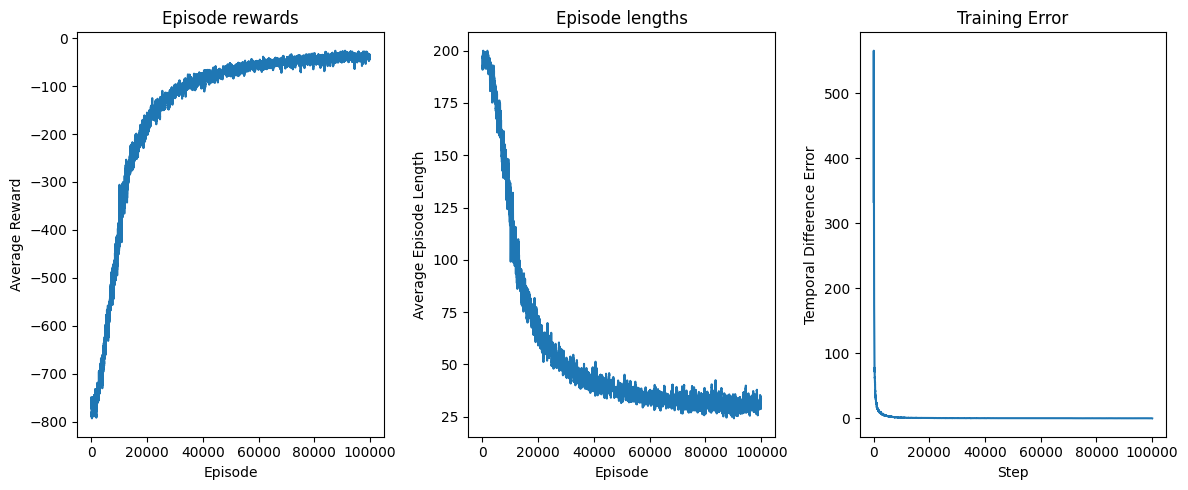

In [48]:
import importlib
import utils_taxi
importlib.reload(utils_taxi)
utils_taxi.graficar_entrenamiento(env=env, agent=agent, rolling_length=100)

In [28]:
# # Current estimate: Q(state, action)
# current_q = self.q_values[obs][action]

# # What we actually experienced: reward + discounted future value
# target = reward + self.discount_factor * max(self.q_values[next_obs])

# # How wrong were we?
# error = target - current_q

# # Update estimate: move toward the target
# new_q = current_q + learning_rate * error

In [29]:
import importlib
import taxi_gif
importlib.reload(taxi_gif)
print("Key episodes (every 10% of training):")
for i, episode in enumerate(key_episodes):
    print(f"Episode {i * (n_episodes // 10)}")
    taxi_gif.animar_estados_taxi_gif(secuencia_estados=episode, nombre_archivo=f"gifs/episode_{i * (n_episodes // 10)}.gif", fps=5)

Key episodes (every 10% of training):


NameError: name 'key_episodes' is not defined

## Montecarlo Off-policy 


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym

# @title Diseño del Agente Monte Carlo Off-Policy

class TaxiAgentOffPolicy:
    def __init__(
        self,
        env: gym.Env,
        epsilon: float = 0.4,
        initial_epsilon: float = 1.0,
        epsilon_decay: float = 0.01,
        final_epsilon: float = 0.01,
        discount_factor: float = 1.0,
        decay=False
    ):
        """Inicializamos todo lo necesario para el aprendizaje Off-Policy"""
        self.env = env
        self.epsilon = epsilon
        self.discount_factor = discount_factor
        self.decay = decay
        self.initial_epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon
        
        self.training_error = []

        # Inicializamos la tabla Q y la matriz C (pesos acumulados en lugar de visitas)
        self.Q = np.zeros([env.observation_space.n, env.action_space.n])
        self.C = np.zeros([env.observation_space.n, env.action_space.n])

    def get_action(self, state) -> int:
        """
        Política de comportamiento (b): epsilon-greedy.
        La utilizamos exclusivamente para explorar el entorno y generar episodios.
        """
        if np.random.random() < self.epsilon:
            return self.env.action_space.sample()
        else:
            return int(np.argmax(self.Q[state, :]))

    def update(
        self,
        episode
    ):
        """
        Algoritmo Monte Carlo Off-Policy.
        Aplicamos el Muestreo de Importancia siguiendo el esquema proporcionado.
        """
        G = 0.0
        W = 1.0
        
        # Recorremos el episodio hacia atrás
        for state, action, reward in reversed(episode):
            G = reward + self.discount_factor * G
            
            # Actualizamos la matriz de pesos acumulados C
            self.C[state, action] += W
            
            # Actualizamos el valor Q ponderado por W/C
            self.Q[state, action] += (W / self.C[state, action]) * (G - self.Q[state, action])
            
            # Obtenemos la mejor acción según nuestra política objetivo (pi), que es codiciosa
            best_action = int(np.argmax(self.Q[state, :]))
            
            # Si la acción del episodio no es la óptima, rompemos el bucle
            if action != best_action:
                break
                
            # Calculamos la probabilidad de que nuestra política de comportamiento (b)
            # hubiera tomado esta acción óptima. Al ser epsilon-greedy:
            prob_b = (1.0 - self.epsilon) + (self.epsilon / self.env.action_space.n)
            
            # Actualizamos el peso W para el siguiente paso hacia atrás
            # Multiplicamos por pi(A|S) / b(A|S). Como pi es determinista, pi(A|S) = 1.0
            W = W * (1.0 / prob_b)

    def decay_epsilon(self, t):
        """Aplicamos el decaimiento de epsilon si está activado."""
        if self.decay:
            self.epsilon = max(self.final_epsilon, self.initial_epsilon / (self.epsilon_decay * t + 1))



In [37]:
env = gym.make("Taxi-v3")

n_episodes = 100_000        # Number of hands to practice
start_epsilon = 1.0         # Start with 100% random actions
epsilon_decay = start_epsilon / (n_episodes / 2)  # Reduce exploration over time
final_epsilon = 0.1         # Always keep some exploration

agent = TaxiAgentOffPolicy(
    env=env,
    epsilon=start_epsilon,
    decay=True,
    discount_factor=1.0,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon
)
Q, rewards, episode_lengths = train_agent(agent, num_episodes=n_episodes)

100%|██████████| 100000/100000 [03:01<00:00, 551.70it/s]


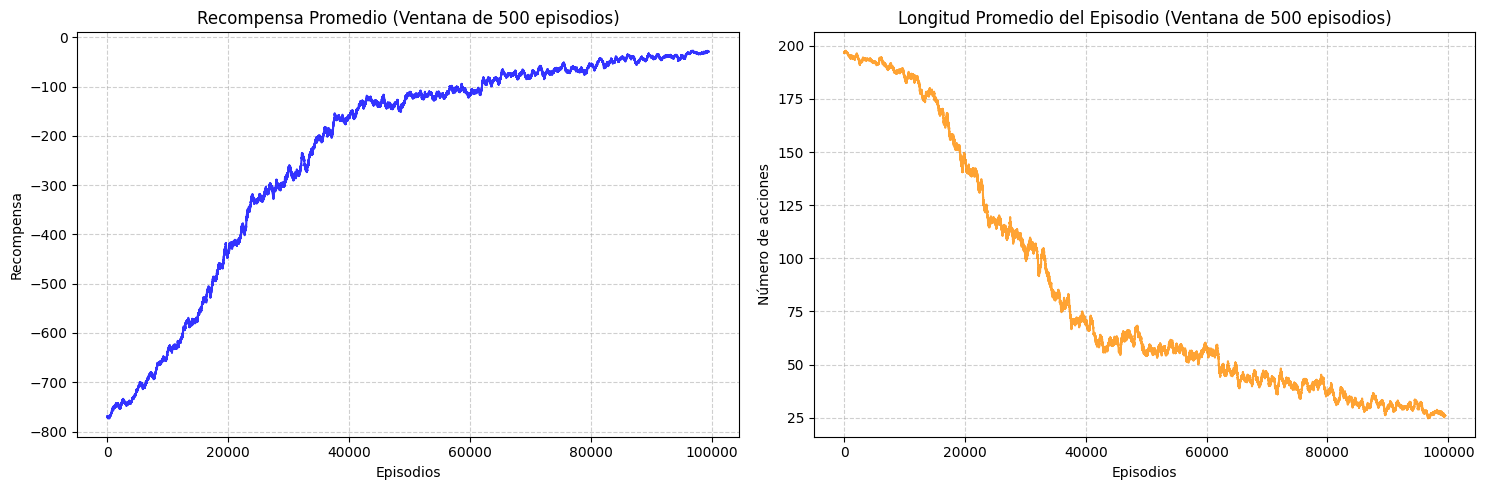

In [38]:
utils_taxi.graficar_entrenamiento(rewards, episode_lengths, ventana=500)